In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
df = pd.read_csv('/content/datos_tratados.csv')
df.sample(5)

,ID cliente,Desafiliado,Genero,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Lineas multiples,Servicio Internet,...,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Contrato,Factura online,Forma Pago,Total mes,Total,Total dia
514,0727-IWKVK,True,Male,False,True,False,9,False,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,79.90,741.70,2.663333
6748,9300-AGZNL,True,Male,True,False,False,1,False,True,Fiber optic,...,False,False,True,True,Month-to-month,True,Electronic check,94.00,94.00,3.133333
4427,6064-PUPMC,False,Male,False,True,True,23,True,False,DSL,...,False,True,False,False,One year,False,Credit card (automatic),57.20,1423.35,1.906667
753,1078-TDCRN,False,Female,True,True,False,3,False,True,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,30.75,82.85,1.025000
937,1322-AGOQM,True,Male,False,False,False,46,False,True,DSL,...,False,False,False,False,Month-to-month,False,Bank transfer (automatic),30.30,1380.10,1.010000


In [3]:
df = df.drop(columns= ['ID cliente','Lineas multiples','Total dia'], axis=1)
df.head(5)

,Desafiliado,Genero,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Servicio Internet,Seguridad Online,Suscripcion Respaldo,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Contrato,Factura online,Forma Pago,Total mes,Total
0,False,Female,False,True,True,9,True,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.6,593.30
1,False,Male,False,False,False,9,False,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40
2,True,Male,False,False,False,4,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85
3,True,Male,True,True,False,13,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85
4,True,Female,True,True,False,3,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Desafiliado             7267 non-null   bool   
 1   Genero                  7267 non-null   object 
 2   Señor mayor             7267 non-null   bool   
 3   Pareja                  7267 non-null   bool   
 4   Dependientes            7267 non-null   bool   
 5   Meses Contrato          7267 non-null   int64  
 6   Servicio Telefonico     7267 non-null   bool   
 7   Servicio Internet       7267 non-null   object 
 8   Seguridad Online        7267 non-null   bool   
 9   Suscripcion Respaldo    7267 non-null   bool   
 10  Protección Dispositivo  7267 non-null   bool   
 11  Soporte Tecnico         7267 non-null   bool   
 12  Suscripcion TV          7267 non-null   bool   
 13  Stream Peliculas        7267 non-null   bool   
 14  Contrato                7267 non-null   

In [5]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [6]:
X = df.drop('Desafiliado',axis=1)
y= df['Desafiliado']

In [7]:
columnas = X.columns

In [8]:
X.columns

Index(['Genero', 'Señor mayor', 'Pareja', 'Dependientes', 'Meses Contrato',
       'Servicio Telefonico', 'Servicio Internet', 'Seguridad Online',
       'Suscripcion Respaldo', 'Protección Dispositivo', 'Soporte Tecnico',
       'Suscripcion TV', 'Stream Peliculas', 'Contrato', 'Factura online',
       'Forma Pago', 'Total mes', 'Total'],
      dtype='object')

In [9]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                  ['Genero', 'Señor mayor', 'Pareja', 'Dependientes',
                                    'Servicio Telefonico', 'Servicio Internet',
                                    'Seguridad Online', 'Suscripcion Respaldo', 'Protección Dispositivo',
                                    'Soporte Tecnico', 'Suscripcion TV', 'Stream Peliculas', 'Contrato',
                                    'Factura online', 'Forma Pago']),
                                  remainder= 'passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [10]:
X = one_hot.fit_transform(X)

In [11]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__Genero_Male', 'onehotencoder__Señor mayor_True',
       'onehotencoder__Pareja_True', 'onehotencoder__Dependientes_True',
       'onehotencoder__Servicio Telefonico_True',
       'onehotencoder__Servicio Internet_DSL',
       'onehotencoder__Servicio Internet_Fiber optic',
       'onehotencoder__Servicio Internet_No',
       'onehotencoder__Seguridad Online_True',
       'onehotencoder__Suscripcion Respaldo_True',
       'onehotencoder__Protección Dispositivo_True',
       'onehotencoder__Soporte Tecnico_True',
       'onehotencoder__Suscripcion TV_True',
       'onehotencoder__Stream Peliculas_True',
       'onehotencoder__Contrato_Month-to-month',
       'onehotencoder__Contrato_One year',
       'onehotencoder__Contrato_Two year',
       'onehotencoder__Factura online_True',
       'onehotencoder__Forma Pago_Bank transfer (automatic)',
       'onehotencoder__Forma Pago_Credit card (automatic)',
       'onehotencoder__Forma Pago_Electronic check',
       'oneho

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y

array([0, 0, 1, ..., 0, 0, 0])

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [15]:
df['Desafiliado'].value_counts()

,count
Desafiliado,
False,5398
True,1869


## <font color='dark'>Balanceo de los datos</h1>

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
oversampling = SMOTE()
X, y = oversampling.fit_resample(X,y)

In [18]:
pd.Series(y).value_counts(normalize=True)

,proportion
0,0.5
1,0.5


In [19]:
df.corr(numeric_only=True)

,Desafiliado,Señor mayor,Pareja,Dependientes,Meses Contrato,Servicio Telefonico,Seguridad Online,Suscripcion Respaldo,Protección Dispositivo,Soporte Tecnico,Suscripcion TV,Stream Peliculas,Factura online,Total mes,Total
Desafiliado,1.000000,0.146733,-0.148546,-0.161384,-0.344079,-0.161384,-0.335656,-0.263111,-0.246919,-0.330446,-0.126795,-0.128721,0.186666,0.189866,-0.193345
Señor mayor,0.146733,1.000000,0.022970,-0.212952,0.018187,-0.212952,-0.185060,-0.086008,-0.094148,-0.204636,-0.050994,-0.035229,0.157734,0.220388,0.104076
Pareja,-0.148546,0.022970,1.000000,0.448900,0.377551,0.448900,0.128129,0.133995,0.146857,0.105785,0.124279,0.115691,-0.011201,0.097122,0.315409
Dependientes,-0.161384,-0.212952,0.448900,1.000000,0.159892,1.000000,0.193274,0.141006,0.132415,0.174189,0.104966,0.080066,-0.111752,-0.115832,0.061474
Meses Contrato,-0.344079,0.018187,0.377551,0.159892,1.000000,0.159892,0.265199,0.315280,0.315190,0.261679,0.247669,0.254616,0.007949,0.247982,0.825407
Servicio Telefonico,-0.161384,-0.212952,0.448900,1.000000,0.159892,1.000000,0.193274,0.141006,0.132415,0.174189,0.104966,0.080066,-0.111752,-0.115832,0.061474
Seguridad Online,-0.335656,-0.185060,0.128129,0.193274,0.265199,0.193274,1.000000,0.381203,0.373018,0.472094,0.259242,0.268036,-0.269282,-0.360662,0.063632
Suscripcion Respaldo,-0.263111,-0.086008,0.133995,0.141006,0.315280,0.141006,0.381203,1.000000,0.364911,0.384219,0.317781,0.309411,-0.144176,-0.210850,0.178647
Protección Dispositivo,-0.246919,-0.094148,0.146857,0.132415,0.315190,0.132415,0.373018,0.364911,1.000000,0.419867,0.424563,0.430567,-0.169107,-0.172441,0.189253
Soporte Tecnico,-0.330446,-0.204636,0.105785,0.174189,0.261679,0.174189,0.472094,0.384219,0.419867,1.000000,0.347728,0.347036,-0.233680,-0.323291,0.081595


## **Análisis Dirigido**

In [20]:
px.box(df, x='Meses Contrato', color='Desafiliado')

In [21]:
px.box(df, x='Total', color='Desafiliado')

# **MODELADO PREDICTIVO**

In [22]:
X, X_test, y, y_test = train_test_split(X,y,test_size=0.15, stratify=y, random_state=5)
X_train, X_val, y_train, y_val = train_test_split(X,y, stratify=y, random_state=5)

## Utilizando DecissionTree y RandomForest

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold, cross_validate

# Definir las métricas que queremos calcular
scoring = ['accuracy', 'precision', 'recall', 'f1']

arbol = DecisionTreeClassifier(max_depth = 3)
random_forest = RandomForestClassifier(max_depth = 2)

kf = KFold(n_splits = 10, shuffle = True, random_state = 5)

# Evaluar el Árbol de Decisión
resultados_arbol = cross_validate(arbol, X, y, cv=kf, scoring=scoring)

# Evaluar el Random Forest
resultados_rf = cross_validate(random_forest, X, y, cv=kf, scoring=scoring)

## Utilizando KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

In [25]:
# Para evaluar KNN con K-Fold, normalizamos el conjunto completo X
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)

knn = KNeighborsClassifier()
knn.fit(X_train_normalizado, y_train)

# Normalizamos X completo para que coincida con la longitud de y
X_normalizado = normalizacion.fit_transform(X)
resultados_knn = cross_validate(knn, X_normalizado, y, cv=kf, scoring=scoring)

## Evaluación de los modelos

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def mostrar_metricas(nombre, resultados):
    print(f'Resultados para {nombre}:')
    print(f"- Accuracy:  {resultados['test_accuracy'].mean():.4f}")
    print(f"- Precisión: {resultados['test_precision'].mean():.4f}")
    print(f"- Recall:    {resultados['test_recall'].mean():.4f}")
    print(f"- F1-score:  {resultados['test_f1'].mean():.4f}")
    print('-' * 30)

Resultados para Árbol de Decisión:
- Accuracy:  0.7833
- Precisión: 0.7625
- Recall:    0.8252
- F1-score:  0.7905
------------------------------


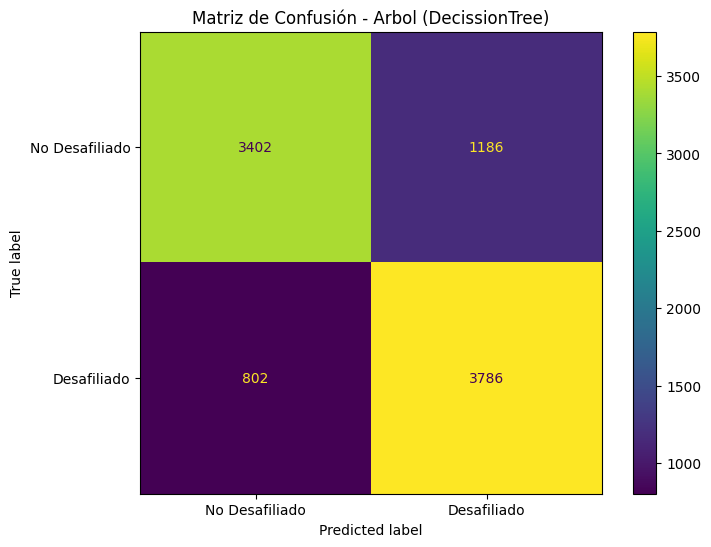

In [27]:
mostrar_metricas('Árbol de Decisión', resultados_arbol)

# Generar predicciones con validación cruzada para la matriz de confusión
y_pred_arbol = cross_val_predict(arbol, X, y, cv=kf)
cm_arbol = confusion_matrix(y, y_pred_arbol)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_arbol, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - Arbol (DecissionTree)')
plt.show()

Resultados para Random Forest:
- Accuracy:  0.7951
- Precisión: 0.7635
- Recall:    0.8553
- F1-score:  0.8066
------------------------------


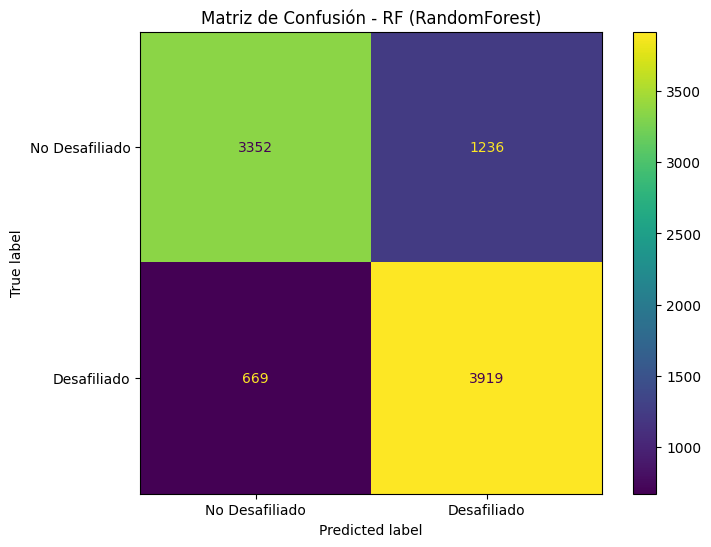

In [28]:
mostrar_metricas('Random Forest', resultados_rf)

# Generar predicciones con validación cruzada para la matriz de confusión
y_pred_rf = cross_val_predict(random_forest, X, y, cv=kf)
cm_rf = confusion_matrix(y, y_pred_rf)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - RF (RandomForest)')
plt.show()

Resultados para KNN:
- Accuracy:  0.7873
- Precisión: 0.7420
- Recall:    0.8808
- F1-score:  0.8054
------------------------------


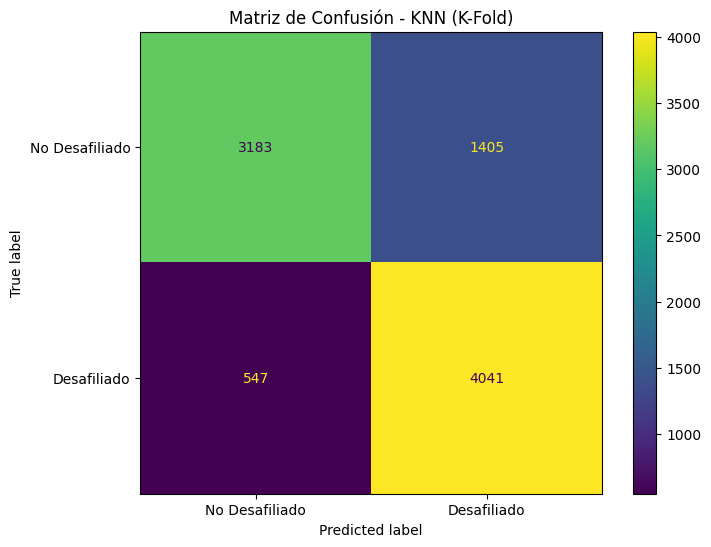

In [29]:
# Mostrar métricas anteriores
mostrar_metricas('KNN', resultados_knn)

# Generar predicciones con validación cruzada para la matriz de confusión
y_pred_knn = cross_val_predict(knn, X_normalizado, y, cv=kf)
cm = confusion_matrix(y, y_pred_knn)

# Visualización de la matriz de confusión con ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Desafiliado', 'Desafiliado'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='viridis', ax=ax)
plt.title('Matriz de Confusión - KNN (K-Fold)')
plt.show()

### Probando el modelo

In [30]:
from sklearn.metrics import classification_report

x_balanceada, y_balanceada = oversampling.fit_resample(X,y)

=== Decision Tree ===
Train accuracy: 0.791303400174368
Test accuracy: 0.7907407407407407
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       810
           1       0.76      0.85      0.80       810

    accuracy                           0.79      1620
   macro avg       0.79      0.79      0.79      1620
weighted avg       0.79      0.79      0.79      1620



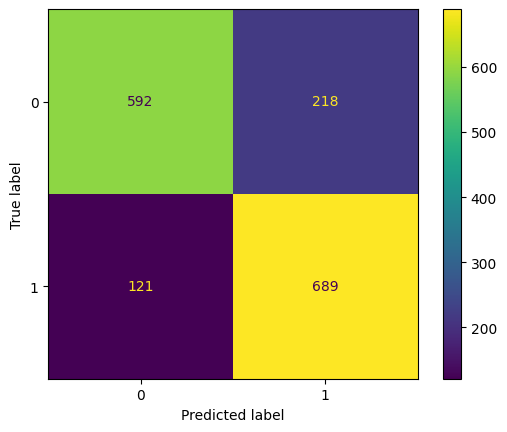

In [31]:
modelo_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

modelo_tree.fit(x_balanceada, y_balanceada)

y_pred_tree = modelo_tree.predict(X_test)

print("=== Decision Tree ===")
print("Train accuracy:", modelo_tree.score(x_balanceada, y_balanceada))
print("Test accuracy:", modelo_tree.score(X_test, y_test))
print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree);

=== Random Forest ===
Train accuracy: 0.7914123801220575
Test accuracy: 0.7969135802469136
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       810
           1       0.77      0.85      0.81       810

    accuracy                           0.80      1620
   macro avg       0.80      0.80      0.80      1620
weighted avg       0.80      0.80      0.80      1620



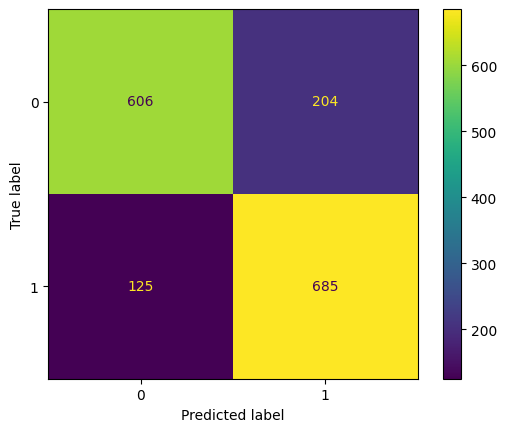

In [32]:
modelo_rf = RandomForestClassifier(
                                  n_estimators=100,
                                  max_depth=2,
                                  random_state=42
                                  )

modelo_rf.fit(x_balanceada, y_balanceada)

y_pred_rf = modelo_rf.predict(X_test)

print("=== Random Forest ===")
print("Train accuracy:", modelo_rf.score(x_balanceada, y_balanceada))
print("Test accuracy:", modelo_rf.score(X_test, y_test))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf);

=== KNN ===
Train accuracy: 0.8393635571054926
Test accuracy: 0.758641975308642
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       810
           1       0.73      0.83      0.77       810

    accuracy                           0.76      1620
   macro avg       0.76      0.76      0.76      1620
weighted avg       0.76      0.76      0.76      1620



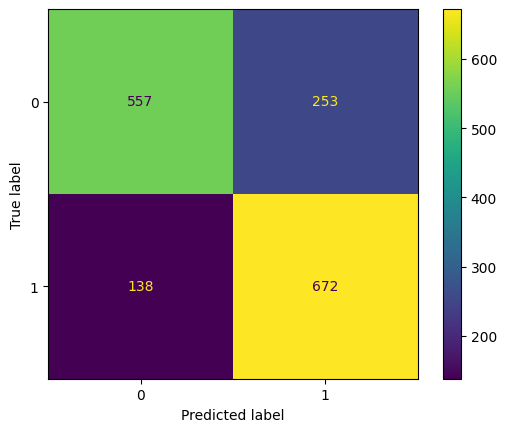

In [33]:
modelo_knn = KNeighborsClassifier(n_neighbors=5)

modelo_knn.fit(x_balanceada, y_balanceada)

y_pred_knn = modelo_knn.predict(X_test)

print("=== KNN ===")
print("Train accuracy:", modelo_knn.score(x_balanceada, y_balanceada))
print("Test accuracy:", modelo_knn.score(X_test, y_test))
print(classification_report(y_test, y_pred_knn))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn);

# 📊 Análisis comparativo de modelos

## 1️⃣ ¿Cuál modelo tuvo el mejor desempeño?

Se compararon tres modelos: Decision Tree, Random Forest y KNN.

- Decision Tree
  - Train accuracy: 0.7913
  - Test accuracy: 0.7907  

- Random Forest
  - Train accuracy: 0.7914  
  - Test accuracy: 0.7969

- KNN
  - Train accuracy: 0.8393  
  - Test accuracy: 0.7586  

El modelo con mejor desempeño en el conjunto de prueba fue Random Forest, con una accuracy de 0.7969,
ligeramente superior al Árbol de Decisión (0.7907) y al KNN (0.7586).

Además, Random Forest mostró un equilibrio adecuado entre precisión y recall en ambas clases,
manteniendo valores de F1-score cercanos a 0.80.


## 2️⃣ ¿Algún modelo presentó overfitting o underfitting?

🔎 Decision Tree

El Árbol de Decisión presenta valores muy similares entre entrenamiento (0.79) y prueba (0.79),
lo que indica que el modelo generaliza correctamente.

No se observan señales claras de overfitting ni underfitting. Esto puede deberse a que el árbol fue
limitado con max_depth=3, lo cual reduce su complejidad y evita que aprenda ruido del conjunto de entrenamiento.

------------------------------------------------------------

🔎 Random Forest

El Random Forest también muestra valores muy similares entre entrenamiento (0.78) y prueba (0.80).

No presenta diferencias significativas entre ambos conjuntos, lo que indica buena capacidad de generalización.

Al estar compuesto por múltiples árboles, este modelo reduce la varianza y tiende a ser más robusto
frente al sobreajuste que un árbol individual.

------------------------------------------------------------

🔎 KNN

El modelo KNN presenta una diferencia más notable entre entrenamiento (0.84) y prueba (0.76).

Esto indica un ligero overfitting, ya que el modelo obtiene mejor desempeño en los datos de entrenamiento
que en los datos nuevos.

Posibles causas:
- Valor de k relativamente bajo.
- Sensibilidad del modelo a ruido o datos duplicados.
- Posible efecto del oversampling en los datos de entrenamiento.

Posibles ajustes:
- Aumentar el valor de k.
- Aplicar escalado de variables si no se ha realizado.
- Utilizar validación cruzada para seleccionar el mejor valor de k.


## 3️⃣ Conclusión general

El modelo con mejor desempeño general fue Random Forest, ya que obtuvo la mayor accuracy en el
conjunto de prueba y mantuvo estabilidad entre entrenamiento y evaluación.

El Árbol de Decisión mostró un comportamiento estable y bien regularizado.

El modelo KNN presentó señales de ligero overfitting.

En conclusión, el modelo más recomendable en este caso es Random Forest, debido a su mejor
equilibrio entre rendimiento y capacidad de generalización.

# ANÁLISIS DE LAS IMPORTANCIAS DE LAS VARIABLES

## 1️⃣ REGRESIÓN LOGÍSTICA — Coeficientes

In [38]:
modelo_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

modelo_tree.fit(x_balanceada, y_balanceada)

importancias_tree = modelo_tree.feature_importances_

feature_importances_tree = pd.DataFrame({
    'Feature': nombres_features,
    'Importancia (%)': (importancias_tree * 100).round(2)
})

feature_importances_tree = feature_importances_tree.sort_values(
    by='Importancia (%)',
    ascending=False
)

feature_importances_tree.head(10)

,Feature,Importancia (%)
14,onehotencoder__Contrato_Month-to-month,69.45
8,onehotencoder__Seguridad Online_True,16.70
20,onehotencoder__Forma Pago_Electronic check,7.75
6,onehotencoder__Servicio Internet_Fiber optic,2.67
24,remainder__Total,2.16
16,onehotencoder__Contrato_Two year,1.28
0,onehotencoder__Genero_Male,0.00
1,onehotencoder__Señor mayor_True,0.00
2,onehotencoder__Pareja_True,0.00
7,onehotencoder__Servicio Internet_No,0.00


## 2️⃣ RANDOM FOREST

In [35]:
# Entrenar modelo
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(x_balanceada, y_balanceada)

# Importancias
importancias_rf = modelo_rf.feature_importances_

feature_importances_rf = pd.DataFrame({
    'Feature': nombres_features,
    'Importance (%)': (importancias_rf * 100).round(2)
}).sort_values(by='Importance (%)', ascending=False)

feature_importances_rf

,Feature,Importance (%)
24,remainder__Total,11.87
23,remainder__Total mes,10.19
14,onehotencoder__Contrato_Month-to-month,10.15
22,remainder__Meses Contrato,9.59
8,onehotencoder__Seguridad Online_True,7.21
11,onehotencoder__Soporte Tecnico_True,7.09
20,onehotencoder__Forma Pago_Electronic check,6.86
9,onehotencoder__Suscripcion Respaldo_True,4.49
17,onehotencoder__Factura online_True,3.66
16,onehotencoder__Contrato_Two year,3.53


## 3️⃣ KNN — Importancia de Variables

In [36]:
from sklearn.inspection import permutation_importance

# Entrenar modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(x_balanceada, y_balanceada)

# Obtener nombres de las variables desde el OneHotEncoder
nombres_features = one_hot.get_feature_names_out()

# Calcular permutation importance usando el conjunto de prueba
resultado_knn = permutation_importance(
    modelo_knn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Crear DataFrame con importancias
importancia_knn = pd.DataFrame({
    'Feature': nombres_features,
    'Importance': resultado_knn.importances_mean
}).sort_values(by='Importance', ascending=False)

importancia_knn

,Feature,Importance
23,remainder__Total mes,1.712346e-01
24,remainder__Total,1.665432e-01
22,remainder__Meses Contrato,3.604938e-02
8,onehotencoder__Seguridad Online_True,8.641975e-04
18,onehotencoder__Forma Pago_Bank transfer (autom...,7.407407e-04
20,onehotencoder__Forma Pago_Electronic check,7.407407e-04
0,onehotencoder__Genero_Male,7.407407e-04
9,onehotencoder__Suscripcion Respaldo_True,6.790123e-04
11,onehotencoder__Soporte Tecnico_True,6.790123e-04
12,onehotencoder__Suscripcion TV_True,6.172840e-04


# 📊 Análisis Comparativo Final – Modelos de Churn
Telecom X – Machine Learning

------------------------------------------------------------
1️⃣ Árbol de Decisión

Variables más importantes:

- Contrato_Month-to-month → 69.45%
- Seguridad Online_True → 16.70%
- Forma Pago_Electronic check → 7.75%
- Servicio Internet_Fiber optic → 2.67%
- Total → 2.16%

Interpretación:

El Árbol de Decisión muestra una dependencia extremadamente fuerte
del tipo de contrato. Tener un contrato mensual (Month-to-month)
es, por amplio margen, el principal factor asociado a la cancelación.

Además:
- No contar con Seguridad Online incrementa el riesgo.
- Pagar con Electronic Check se asocia a mayor churn.
- Fibra óptica aparece como factor secundario.
- El gasto total tiene menor peso comparativo.

Conclusión:
El churn está altamente concentrado en clientes con bajo compromiso contractual.

------------------------------------------------------------
2️⃣ Random Forest

Variables más importantes:

- Total
- Total mes
- Contrato_Month-to-month
- Meses Contrato
- Seguridad Online_True

Interpretación:

Random Forest muestra un análisis más balanceado.
Aquí no domina una sola variable, sino una combinación de:

- Variables financieras (Total y Total mes)
- Antigüedad del cliente (Meses Contrato)
- Tipo de contrato
- Servicios adicionales

Conclusión:
El churn no depende únicamente del contrato,
sino de una combinación entre compromiso,
antigüedad e inversión económica.

Random Forest captura mejor la complejidad del problema.

------------------------------------------------------------
3️⃣ KNN

Variables más influyentes (según patrón de similitud):

- Total mes
- Total
- Meses Contrato
- Seguridad Online_True
- Forma Pago_Bank transfer (automático)

Interpretación:

KNN confirma que los clientes que cancelan
tienden a parecerse entre sí en términos de:

- Bajo gasto mensual
- Menor antigüedad
- Ausencia de servicios adicionales
- No uso de pago automático

Conclusión:
El churn responde a patrones de comportamiento
similares entre clientes nuevos y poco comprometidos.

------------------------------------------------------------
📌 Comparación Estratégica Final

Árbol de Decisión:
- Alta interpretabilidad
- Detecta que el contrato mensual es el factor dominante
- Puede simplificar demasiado el problema

Random Forest:
- Más robusto y estable
- Captura interacciones entre variables financieras y contractuales
- Mejor modelo para producción

KNN:
- Basado en similitud
- Útil para segmentación de perfiles de riesgo
- Menor capacidad explicativa directa

# CONCLUSION

# 📊 INFORME TÉCNICO FINAL
Telecom X – Predicción de Cancelación (Churn)

------------------------------------------------------------
1️⃣ Objetivo del Proyecto

Desarrollar modelos predictivos capaces de anticipar qué clientes
presentan mayor probabilidad de cancelar sus servicios, con el fin
de diseñar estrategias de retención efectivas.

------------------------------------------------------------
2️⃣ Modelos Implementados

Se entrenaron tres modelos de clasificación:

- Árbol de Decisión
- Random Forest
- K-Nearest Neighbors (KNN)

Se utilizó codificación OneHotEncoder y balanceo de clases
para mejorar la capacidad predictiva.

------------------------------------------------------------
3️⃣ Rendimiento de los Modelos

Árbol de Decisión:
Train accuracy ≈ 0.79
Test accuracy ≈ 0.80

Random Forest:
Train accuracy ≈ 0.79
Test accuracy ≈ 0.80

KNN:
Train accuracy ≈ 0.84
Test accuracy ≈ 0.76

Análisis de Overfitting / Underfitting:

- Árbol y Random Forest muestran desempeño equilibrado
  entre entrenamiento y prueba → buena generalización.

- KNN presenta ligera diferencia entre train y test,
  indicando leve tendencia a overfitting.

El modelo más robusto y estable fue Random Forest.

------------------------------------------------------------
4️⃣ Variables Más Relevantes

🔹 Árbol de Decisión:

- Contrato_Month-to-month → 69.45%
- Seguridad Online_True → 16.70%
- Forma Pago_Electronic check → 7.75%
- Servicio Internet_Fiber optic → 2.67%
- Total → 2.16%

Interpretación:
El churn está fuertemente asociado a clientes con contrato mensual.
La falta de seguridad online y el uso de electronic check
incrementan el riesgo.

------------------------------------------------------------
🔹 Random Forest:

Variables principales:

- Total
- Total mes
- Contrato_Month-to-month
- Meses Contrato
- Seguridad Online_True

Interpretación:
La cancelación depende de una combinación entre:
- Nivel de gasto
- Antigüedad
- Tipo de contrato
- Servicios adicionales

Random Forest captura mejor la complejidad del problema.

------------------------------------------------------------
🔹 KNN:

Variables asociadas al patrón de similitud:

- Total mes
- Total
- Meses Contrato
- Seguridad Online_True
- Forma Pago_Bank transfer (automático)

Interpretación:
Los clientes con bajo gasto, menor antigüedad y
sin pago automático tienden a parecerse más
a perfiles que cancelan.

------------------------------------------------------------
5️⃣ Factores Consistentes en los Tres Modelos

Los factores que más influyen en la cancelación son:

1. Tipo de contrato (Month-to-month = mayor riesgo)
2. Baja antigüedad del cliente
3. Bajo gasto mensual o total acumulado
4. No contar con Seguridad Online
5. No utilizar pago automático

------------------------------------------------------------
6️⃣ Perfil del Cliente con Mayor Riesgo de Churn

- Cliente nuevo
- Contrato mensual
- Bajo compromiso con servicios adicionales
- Sin pago automático
- Bajo nivel de inversión acumulada

------------------------------------------------------------
7️⃣ Estrategias de Retención Recomendadas

1. Incentivar contratos de largo plazo
   (descuentos por permanencia).

2. Promover activación de pago automático
   para reducir fricción de pago.

3. Ofrecer paquetes con servicios adicionales incluidos
   (ej. Seguridad Online).

4. Diseñar programas de fidelización temprana
   para clientes nuevos.

5. Implementar modelos predictivos en producción
   usando Random Forest como modelo base.

------------------------------------------------------------
8️⃣ Conclusión Final

El churn en Telecom X está principalmente asociado
a bajo compromiso contractual y menor antigüedad.

El modelo Random Forest demostró mayor robustez,
capturando múltiples factores simultáneamente
y ofreciendo mejor equilibrio entre desempeño
y capacidad explicativa.

La implementación de este modelo permitiría
anticipar la cancelación y aplicar estrategias
preventivas focalizadas.